# SINDy on Yield-Curve Factor Dynamics

This notebook applies the from-scratch SINDy implementation to a simple yield-curve factor system.

We construct three observable proxies from FRED Treasury constant-maturity yields:

- `level = DGS10`
- `slope = DGS10 - DGS2`
- `curvature = 2*DGS5 - DGS2 - DGS10`

The goal is to test whether SINDy can identify sparse, interpretable dynamics in daily changes of yield-curve factors.

We deliberately compare a linear library and a quadratic/mixed library to demonstrate the SINDy candidate-library idea.

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import io

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from src.discrete_sindy import fit_discrete_sindy, predict_discrete_sindy

## Helper functions

In [8]:
def load_fred_series(series_id):
    """Load one FRED series from the public CSV endpoint."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    response = requests.get(url, timeout=30, verify=certifi.where())
    response.raise_for_status()

    df = pd.read_csv(io.StringIO(response.text))
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")

    return df[["observation_date", series_id]]


def print_equations(feature_names, Xi, target_names, tolerance=1e-12):
    """Print sparse equations from a coefficient matrix."""
    for target_idx, target_name in enumerate(target_names):
        terms = []

        for feature_name, coefficient in zip(feature_names, Xi[:, target_idx]):
            if abs(coefficient) <= tolerance:
                continue

            if feature_name == "1":
                terms.append(f"{coefficient:.6g}")
            else:
                terms.append(f"{coefficient:.6g}*{feature_name}")

        equation = " + ".join(terms) if terms else "0"
        print(f"{target_name} = {equation}")

## Load Treasury yield data

We use FRED constant-maturity Treasury yields:

- `DGS2`: 2-year Treasury yield
- `DGS5`: 5-year Treasury yield
- `DGS10`: 10-year Treasury yield

The values are quoted in percent, so we convert them to decimals.

In [9]:
dgs2 = load_fred_series("DGS2")
dgs5 = load_fred_series("DGS5")
dgs10 = load_fred_series("DGS10")

yield_curve = dgs2.merge(dgs5, on="observation_date", how="inner")
yield_curve = yield_curve.merge(dgs10, on="observation_date", how="inner")
yield_curve = yield_curve.dropna().reset_index(drop=True)

print(yield_curve.head())
print(yield_curve.tail())
print("Number of observations:", len(yield_curve))

  observation_date  DGS2  DGS5  DGS10
0       1976-06-01  7.26  7.71   7.94
1       1976-06-02  7.23  7.74   7.94
2       1976-06-03  7.22  7.75   7.92
3       1976-06-04  7.12  7.67   7.89
4       1976-06-07  7.09  7.64   7.88
      observation_date  DGS2  DGS5  DGS10
12467       2026-04-21  3.78  3.91   4.30
12468       2026-04-22  3.79  3.91   4.30
12469       2026-04-23  3.83  3.96   4.34
12470       2026-04-24  3.78  3.92   4.31
12471       2026-04-27  3.78  3.94   4.35
Number of observations: 12472


## Build level, slope, and curvature proxies

We use simple observable proxies:

`level = 10Y yield`

`slope = 10Y yield - 2Y yield`

`curvature = 2*5Y yield - 2Y yield - 10Y yield`

This is not a full Nelson-Siegel estimation, but it gives a compact three-dimensional representation of the curve shape.

In [10]:
yield_curve["y2"] = yield_curve["DGS2"] / 100.0
yield_curve["y5"] = yield_curve["DGS5"] / 100.0
yield_curve["y10"] = yield_curve["DGS10"] / 100.0

yield_curve["level"] = yield_curve["y10"]
yield_curve["slope"] = yield_curve["y10"] - yield_curve["y2"]
yield_curve["curvature"] = 2.0 * yield_curve["y5"] - yield_curve["y2"] - yield_curve["y10"]

factor_cols = ["level", "slope", "curvature"]

print(yield_curve[["observation_date"] + factor_cols].head())
print(yield_curve[["observation_date"] + factor_cols].tail())

  observation_date   level   slope  curvature
0       1976-06-01  0.0794  0.0068     0.0022
1       1976-06-02  0.0794  0.0071     0.0031
2       1976-06-03  0.0792  0.0070     0.0036
3       1976-06-04  0.0789  0.0077     0.0033
4       1976-06-07  0.0788  0.0079     0.0031
      observation_date   level   slope  curvature
12467       2026-04-21  0.0430  0.0052    -0.0026
12468       2026-04-22  0.0430  0.0051    -0.0027
12469       2026-04-23  0.0434  0.0051    -0.0025
12470       2026-04-24  0.0431  0.0053    -0.0025
12471       2026-04-27  0.0435  0.0057    -0.0025


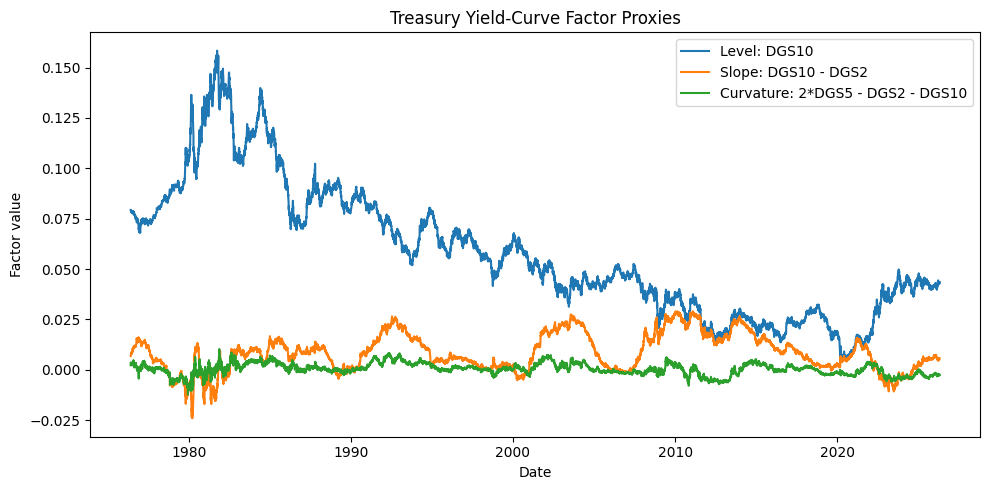

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(yield_curve["observation_date"], yield_curve["level"], label="Level: DGS10")
plt.plot(yield_curve["observation_date"], yield_curve["slope"], label="Slope: DGS10 - DGS2")
plt.plot(yield_curve["observation_date"], yield_curve["curvature"], label="Curvature: 2*DGS5 - DGS2 - DGS10")
plt.xlabel("Date")
plt.ylabel("Factor value")
plt.title("Treasury Yield-Curve Factor Proxies")
plt.legend()
plt.tight_layout()
plt.show()

## Modelling choice: factor changes

Instead of modelling factor levels directly,

`X_next ≈ F(X_current)`,

we model daily factor changes:

`Delta X_next = X_next - X_current ≈ F(X_current)`.

This makes mean-reversion easier to interpret. For example, if the coefficient from `slope` to `Delta slope` is negative, then high slope values are associated with negative future slope changes.

In [12]:
X_factors = yield_curve[factor_cols].to_numpy()

X_current = X_factors[:-1]
X_next = X_factors[1:]
Y_change = X_next - X_current

target_names = ["Delta level", "Delta slope", "Delta curvature"]

print("X_current shape:", X_current.shape)
print("Y_change shape:", Y_change.shape)
print("First 5 X_current:")
print(X_current[:5])
print("First 5 Y_change:")
print(Y_change[:5])

X_current shape: (12471, 3)
Y_change shape: (12471, 3)
First 5 X_current:
[[0.0794 0.0068 0.0022]
 [0.0794 0.0071 0.0031]
 [0.0792 0.007  0.0036]
 [0.0789 0.0077 0.0033]
 [0.0788 0.0079 0.0031]]
First 5 Y_change:
[[ 0.00000000e+00  3.00000000e-04  9.00000000e-04]
 [-2.00000000e-04 -1.00000000e-04  5.00000000e-04]
 [-3.00000000e-04  7.00000000e-04 -3.00000000e-04]
 [-1.00000000e-04  2.00000000e-04 -2.00000000e-04]
 [ 2.00000000e-04  1.38777878e-17  2.00000000e-04]]


## Train/test split

We use the first 80% of observations for training and the last 20% for out-of-sample testing.

The naive baseline is the zero-change model:

`Delta X_next_hat = 0`.

In [13]:
split_idx = int(0.8 * len(X_current))

X_train = X_current[:split_idx]
Y_train = Y_change[:split_idx]

X_test = X_current[split_idx:]
Y_test = Y_change[split_idx:]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 9976
Test samples: 2495


## Model 1: linear SINDy library

With `degree=1`, the library is:

`[1, level, slope, curvature]`

This corresponds to a sparse linear factor-change model:

`Delta X_next ≈ constant + A * X_current`.

In [14]:
Xi_linear, names_linear = fit_discrete_sindy(
    X_train,
    Y_train,
    degree=1,
    threshold=1e-8,
    max_iter=10,
)

Y_test_hat_linear = predict_discrete_sindy(
    X_test,
    Xi_linear,
    degree=1,
)

print("Feature names:", names_linear)
print("Xi_linear shape:", Xi_linear.shape)
print("Xi_linear:")
print(Xi_linear)
print()
print("Recovered linear equations:")
print_equations(names_linear, Xi_linear, target_names)

Feature names: ['1', 'x1', 'x2', 'x3']
Xi_linear shape: (4, 3)
Xi_linear:
[[ 3.52165064e-06  4.86521300e-05 -6.48354904e-05]
 [-7.59902775e-05 -4.11299730e-04  7.46956496e-04]
 [ 1.30315192e-05 -2.39350190e-03  2.86492481e-03]
 [-6.73791251e-03  2.69755068e-03 -1.71820327e-02]]

Recovered linear equations:
Delta level = 3.52165e-06 + -7.59903e-05*x1 + 1.30315e-05*x2 + -0.00673791*x3
Delta slope = 4.86521e-05 + -0.0004113*x1 + -0.0023935*x2 + 0.00269755*x3
Delta curvature = -6.48355e-05 + 0.000746956*x1 + 0.00286492*x2 + -0.017182*x3


## Model 2: quadratic and mixed SINDy library

With `degree=2`, the library becomes:

`[1, level, slope, curvature, level^2, level*slope, level*curvature, slope^2, slope*curvature, curvature^2]`

This demonstrates the SINDy idea: allow many candidate terms, then sparsify the coefficient matrix.

In [15]:
Xi_quad, names_quad = fit_discrete_sindy(
    X_train,
    Y_train,
    degree=2,
    threshold=1e-8,
    max_iter=10,
)

Y_test_hat_quad = predict_discrete_sindy(
    X_test,
    Xi_quad,
    degree=2,
)

print("Feature names:", names_quad)
print("Xi_quad shape:", Xi_quad.shape)
print("Xi_quad:")
print(Xi_quad)
print()
print("Recovered quadratic-library equations:")
print_equations(names_quad, Xi_quad, target_names)

Feature names: ['1', 'x1', 'x2', 'x3', 'x1^2', 'x1x2', 'x1x3', 'x2^2', 'x2x3', 'x3^2']
Xi_quad shape: (10, 3)
Xi_quad:
[[-2.58602852e-05 -1.58942682e-04  1.58768192e-04]
 [ 8.35841095e-05  4.54855556e-03 -5.56171191e-03]
 [ 6.95033582e-03  1.36508594e-02 -4.89158762e-03]
 [ 4.02874602e-04 -4.20359290e-02  1.22482663e-02]
 [ 1.50303552e-03 -2.75857358e-02  3.81735111e-02]
 [ 1.10638207e-03 -2.21363546e-01  2.03173740e-01]
 [-2.07132678e-01  5.51582128e-01 -6.18925351e-01]
 [-2.91433988e-01 -2.27470256e-01 -9.41599868e-02]
 [ 1.76703821e-01  1.46078266e+00  1.38756557e-01]
 [ 1.20243134e-01 -1.02090296e+00 -5.87938775e-02]]

Recovered quadratic-library equations:
Delta level = -2.58603e-05 + 8.35841e-05*x1 + 0.00695034*x2 + 0.000402875*x3 + 0.00150304*x1^2 + 0.00110638*x1x2 + -0.207133*x1x3 + -0.291434*x2^2 + 0.176704*x2x3 + 0.120243*x3^2
Delta slope = -0.000158943 + 0.00454856*x1 + 0.0136509*x2 + -0.0420359*x3 + -0.0275857*x1^2 + -0.221364*x1x2 + 0.551582*x1x3 + -0.22747*x2^2 + 1.46078*

## Out-of-sample validation

We compare both SINDy models against the naive zero-change baseline.

For each factor, we compute test MSE:

- `Delta level`
- `Delta slope`
- `Delta curvature`

In [16]:
zero_change_hat = np.zeros_like(Y_test)

mse_naive = np.mean((Y_test - zero_change_hat) ** 2, axis=0)
mse_linear = np.mean((Y_test - Y_test_hat_linear) ** 2, axis=0)
mse_quad = np.mean((Y_test - Y_test_hat_quad) ** 2, axis=0)

results = pd.DataFrame({
    "factor": factor_cols,
    "mse_naive_zero_change": mse_naive,
    "mse_linear_sindy": mse_linear,
    "mse_quadratic_sindy": mse_quad,
    "linear_improvement_vs_naive": mse_naive - mse_linear,
    "quadratic_improvement_vs_naive": mse_naive - mse_quad,
})

print(results)


      factor  mse_naive_zero_change  mse_linear_sindy  mse_quadratic_sindy  \
0      level           2.848417e-07      2.851974e-07         2.860548e-07   
1      slope           1.341202e-07      1.348128e-07         1.346757e-07   
2  curvature           7.005611e-08      7.011367e-08         7.175789e-08   

   linear_improvement_vs_naive  quadratic_improvement_vs_naive  
0                -3.557666e-10                   -1.213113e-09  
1                -6.925844e-10                   -5.554709e-10  
2                -5.755687e-11                   -1.701773e-09  


## Coefficient tables

Rows are library terms. Columns are target changes.

A negative coefficient on `slope` in the `Delta slope` equation suggests slope mean reversion.

A negative coefficient on `curvature` in the `Delta curvature` equation suggests curvature mean reversion.

In [17]:
linear_coef_table = pd.DataFrame(
    Xi_linear,
    index=names_linear,
    columns=target_names,
)

quad_coef_table = pd.DataFrame(
    Xi_quad,
    index=names_quad,
    columns=target_names,
)

print("Linear library coefficient table:")
print(linear_coef_table)
print()
print("Quadratic library coefficient table:")
print(quad_coef_table)

Linear library coefficient table:
    Delta level  Delta slope  Delta curvature
1      0.000004     0.000049        -0.000065
x1    -0.000076    -0.000411         0.000747
x2     0.000013    -0.002394         0.002865
x3    -0.006738     0.002698        -0.017182

Quadratic library coefficient table:
      Delta level  Delta slope  Delta curvature
1       -0.000026    -0.000159         0.000159
x1       0.000084     0.004549        -0.005562
x2       0.006950     0.013651        -0.004892
x3       0.000403    -0.042036         0.012248
x1^2     0.001503    -0.027586         0.038174
x1x2     0.001106    -0.221364         0.203174
x1x3    -0.207133     0.551582        -0.618925
x2^2    -0.291434    -0.227470        -0.094160
x2x3     0.176704     1.460783         0.138757
x3^2     0.120243    -1.020903        -0.058794


## Plot out-of-sample predictions

We plot predicted factor changes against realized factor changes.

The zero line is the naive zero-change baseline.

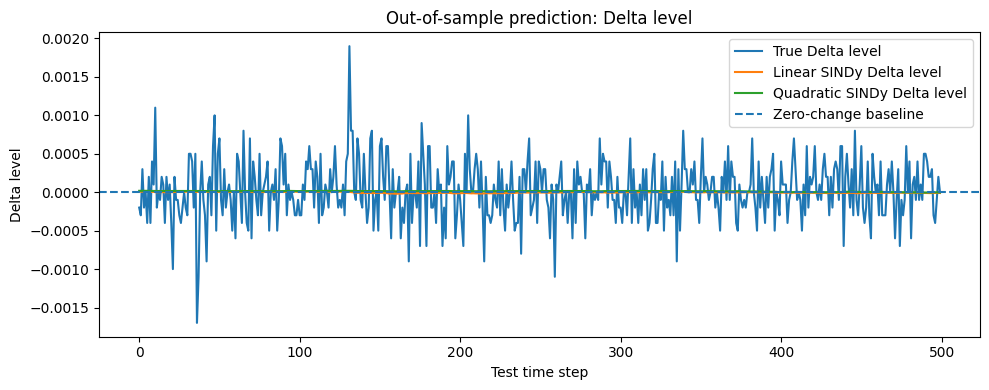

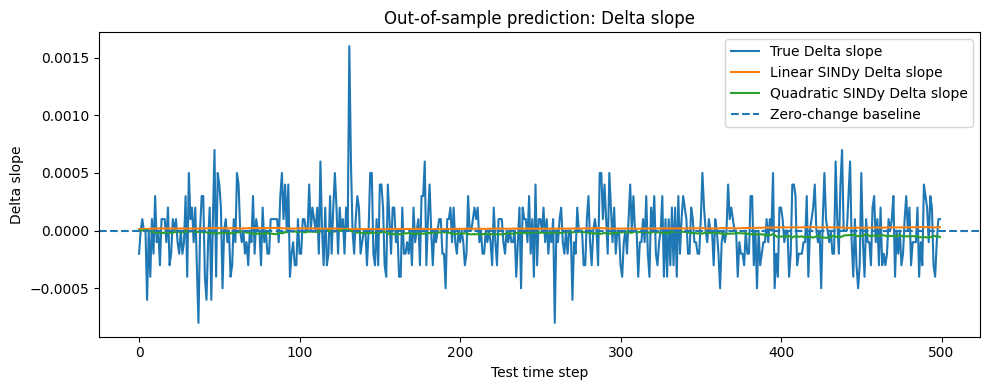

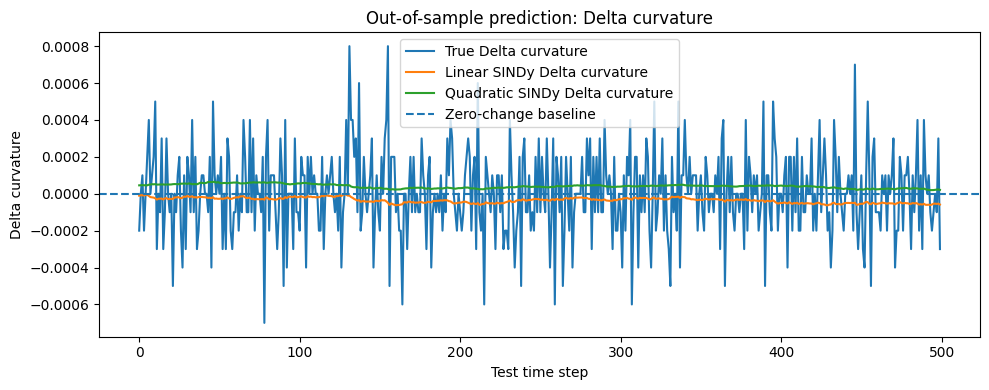

In [18]:
n_plot = 500

for i, factor in enumerate(factor_cols):
    plt.figure(figsize=(10, 4))
    plt.plot(Y_test[:n_plot, i], label=f"True Delta {factor}")
    plt.plot(Y_test_hat_linear[:n_plot, i], label=f"Linear SINDy Delta {factor}")
    plt.plot(Y_test_hat_quad[:n_plot, i], label=f"Quadratic SINDy Delta {factor}")
    plt.axhline(0.0, linestyle="--", label="Zero-change baseline")
    plt.xlabel("Test time step")
    plt.ylabel(f"Delta {factor}")
    plt.title(f"Out-of-sample prediction: Delta {factor}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation guide

This experiment is mainly a demonstration of SINDy as a sparse library-selection method for financial state variables.

The linear library tests a sparse VAR-style change model.

The quadratic library allows nonlinear and interaction terms such as:

- `level^2`
- `level*slope`
- `level*curvature`
- `slope^2`
- `slope*curvature`
- `curvature^2`

The key questions are:

1. Does SINDy select interpretable terms?
2. Are slope and curvature self-coefficients negative in their own change equations?
3. Does the quadratic library improve out-of-sample MSE relative to the linear model and zero-change baseline?
4. Or does it mainly add complexity without robust predictive improvement?

A cautious conclusion is preferred: real yield-curve factor changes are noisy, and any discovered nonlinear terms should be treated as candidate structure rather than proven laws.

## Conclusion

The linear library identifies interpretable mean-reversion-like terms. In particular, the coefficient from `slope` to `Delta slope` is negative, and the coefficient from `curvature` to `Delta curvature` is negative.

However, out-of-sample validation shows that both SINDy models underperform the naive zero-change baseline for daily factor changes.

The quadratic library demonstrates the candidate-library idea of SINDy by allowing nonlinear and mixed terms, but it mainly adds complexity and does not improve out-of-sample performance.

Therefore, the result should be interpreted as a model-discovery exercise rather than a tradable forecasting signal.

## Threshold sweep

The STLSQ threshold controls sparsity.

A small threshold keeps many coefficients active.

A larger threshold removes more coefficients and produces simpler equations.

We test several threshold values for the quadratic library and compare:

- number of active coefficients
- out-of-sample MSE
- improvement versus the zero-change baseline

In [19]:
thresholds = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]

sweep_rows = []

for threshold in thresholds:
    Xi_sweep, names_sweep = fit_discrete_sindy(
        X_train,
        Y_train,
        degree=2,
        threshold=threshold,
        max_iter=10,
    )

    Y_test_hat_sweep = predict_discrete_sindy(
        X_test,
        Xi_sweep,
        degree=2,
    )

    mse_sweep = np.mean((Y_test - Y_test_hat_sweep) ** 2, axis=0)
    active_terms_total = np.sum(np.abs(Xi_sweep) > 0)

    sweep_rows.append({
        "threshold": threshold,
        "active_terms_total": active_terms_total,
        "mse_level": mse_sweep[0],
        "mse_slope": mse_sweep[1],
        "mse_curvature": mse_sweep[2],
        "improvement_level_vs_naive": mse_naive[0] - mse_sweep[0],
        "improvement_slope_vs_naive": mse_naive[1] - mse_sweep[1],
        "improvement_curvature_vs_naive": mse_naive[2] - mse_sweep[2],
    })

threshold_sweep = pd.DataFrame(sweep_rows)

print(threshold_sweep)

      threshold  active_terms_total     mse_level     mse_slope  \
0  1.000000e-08                  30  2.860548e-07  1.346757e-07   
1  1.000000e-07                  30  2.860548e-07  1.346757e-07   
2  1.000000e-06                  30  2.860548e-07  1.346757e-07   
3  1.000000e-05                  30  2.860548e-07  1.346757e-07   
4  1.000000e-04                  27  2.853756e-07  1.346757e-07   
5  1.000000e-03                  22  2.854886e-07  1.346494e-07   

   mse_curvature  improvement_level_vs_naive  improvement_slope_vs_naive  \
0   7.175789e-08               -1.213113e-09               -5.554709e-10   
1   7.175789e-08               -1.213113e-09               -5.554709e-10   
2   7.175789e-08               -1.213113e-09               -5.554709e-10   
3   7.175789e-08               -1.213113e-09               -5.554709e-10   
4   7.175789e-08               -5.339009e-10               -5.554709e-10   
5   6.985638e-08               -6.468964e-10               -5.291704e-10  

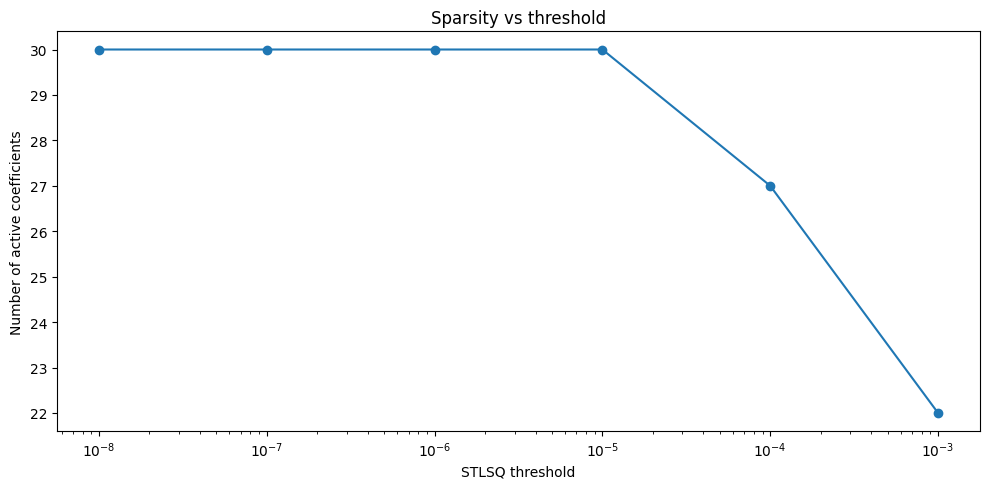

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_sweep["threshold"], threshold_sweep["active_terms_total"], marker="o")
plt.xscale("log")
plt.xlabel("STLSQ threshold")
plt.ylabel("Number of active coefficients")
plt.title("Sparsity vs threshold")
plt.tight_layout()
plt.show()

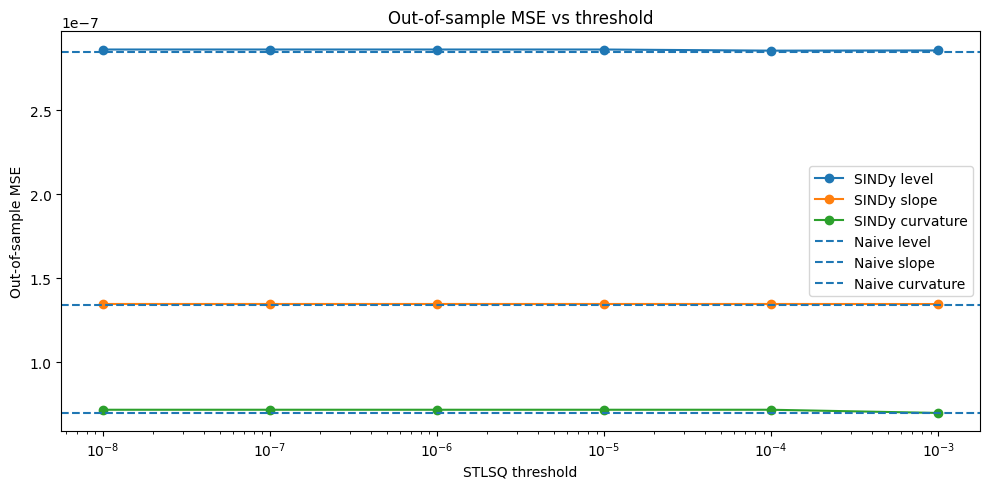

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_sweep["threshold"], threshold_sweep["mse_level"], marker="o", label="SINDy level")
plt.plot(threshold_sweep["threshold"], threshold_sweep["mse_slope"], marker="o", label="SINDy slope")
plt.plot(threshold_sweep["threshold"], threshold_sweep["mse_curvature"], marker="o", label="SINDy curvature")

plt.axhline(mse_naive[0], linestyle="--", label="Naive level")
plt.axhline(mse_naive[1], linestyle="--", label="Naive slope")
plt.axhline(mse_naive[2], linestyle="--", label="Naive curvature")

plt.xscale("log")
plt.xlabel("STLSQ threshold")
plt.ylabel("Out-of-sample MSE")
plt.title("Out-of-sample MSE vs threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
best_threshold_idx = threshold_sweep[["mse_level", "mse_slope", "mse_curvature"]].mean(axis=1).idxmin()
best_threshold = threshold_sweep.loc[best_threshold_idx, "threshold"]

print("Best threshold by average MSE:", best_threshold)

Xi_best, names_best = fit_discrete_sindy(
    X_train,
    Y_train,
    degree=2,
    threshold=best_threshold,
    max_iter=10,
)

best_coef_table = pd.DataFrame(
    Xi_best,
    index=names_best,
    columns=target_names,
)

print(best_coef_table)

print()
print("Recovered equations at best threshold:")
print_equations(names_best, Xi_best, target_names)

Best threshold by average MSE: 0.001
      Delta level  Delta slope  Delta curvature
1        0.000000     0.000000         0.000000
x1       0.000000     0.000000        -0.001971
x2       0.004173     0.006059         0.005604
x3       0.000000    -0.027146        -0.002871
x1^2     0.000000     0.000000         0.019521
x1x2     0.014251    -0.108646         0.091545
x1x3    -0.180684     0.335057        -0.453173
x2^2    -0.231384    -0.136603        -0.269854
x2x3     0.138972     1.134829         0.610258
x3^2     0.057239    -0.705042        -0.462130

Recovered equations at best threshold:
Delta level = 0.00417274*x2 + 0.0142507*x1x2 + -0.180684*x1x3 + -0.231384*x2^2 + 0.138972*x2x3 + 0.0572389*x3^2
Delta slope = 0.00605861*x2 + -0.0271457*x3 + -0.108646*x1x2 + 0.335057*x1x3 + -0.136603*x2^2 + 1.13483*x2x3 + -0.705042*x3^2
Delta curvature = -0.00197092*x1 + 0.00560364*x2 + -0.002871*x3 + 0.0195206*x1^2 + 0.0915454*x1x2 + -0.453173*x1x3 + -0.269854*x2^2 + 0.610258*x2x3 + -0.4621

The threshold sweep shows that very small thresholds leave the quadratic model dense. A threshold of 0.001 reduces active coefficients from 30 to 22 and marginally improves the curvature equation, but level and slope still underperform the zero-change baseline. Hence, sparsification improves interpretability but does not create robust predictive power.

In [23]:
# Extended threshold sweep for stronger sparsity

thresholds_extended = [1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

sweep_rows_extended = []

for threshold in thresholds_extended:
    Xi_sweep, names_sweep = fit_discrete_sindy(
        X_train,
        Y_train,
        degree=2,
        threshold=threshold,
        max_iter=10,
    )

    Y_test_hat_sweep = predict_discrete_sindy(
        X_test,
        Xi_sweep,
        degree=2,
    )

    mse_sweep = np.mean((Y_test - Y_test_hat_sweep) ** 2, axis=0)
    active_terms_total = np.sum(np.abs(Xi_sweep) > 0)

    sweep_rows_extended.append({
        "threshold": threshold,
        "active_terms_total": active_terms_total,
        "mse_level": mse_sweep[0],
        "mse_slope": mse_sweep[1],
        "mse_curvature": mse_sweep[2],
        "improvement_level_vs_naive": mse_naive[0] - mse_sweep[0],
        "improvement_slope_vs_naive": mse_naive[1] - mse_sweep[1],
        "improvement_curvature_vs_naive": mse_naive[2] - mse_sweep[2],
    })

threshold_sweep_extended = pd.DataFrame(sweep_rows_extended)

threshold_sweep_extended["avg_mse"] = threshold_sweep_extended[
    ["mse_level", "mse_slope", "mse_curvature"]
].mean(axis=1)

threshold_sweep_extended["avg_improvement_vs_naive"] = (
    (mse_naive.mean()) - threshold_sweep_extended["avg_mse"]
)

threshold_sweep_extended["avg_improvement_pct_vs_naive"] = (
    threshold_sweep_extended["avg_improvement_vs_naive"] / mse_naive.mean()
) * 100

print(threshold_sweep_extended)

      threshold  active_terms_total     mse_level     mse_slope  \
0  1.000000e-08                  30  2.860548e-07  1.346757e-07   
1  1.000000e-06                  30  2.860548e-07  1.346757e-07   
2  1.000000e-05                  30  2.860548e-07  1.346757e-07   
3  1.000000e-04                  27  2.853756e-07  1.346757e-07   
4  1.000000e-03                  22  2.854886e-07  1.346494e-07   
5  3.000000e-03                  17  2.855805e-07  1.346494e-07   
6  1.000000e-02                  15  2.849514e-07  1.338144e-07   
7  3.000000e-02                  10  2.849544e-07  1.341313e-07   
8  1.000000e-01                   3  2.849446e-07  1.341145e-07   

   mse_curvature  improvement_level_vs_naive  improvement_slope_vs_naive  \
0   7.175789e-08               -1.213113e-09               -5.554709e-10   
1   7.175789e-08               -1.213113e-09               -5.554709e-10   
2   7.175789e-08               -1.213113e-09               -5.554709e-10   
3   7.175789e-08         

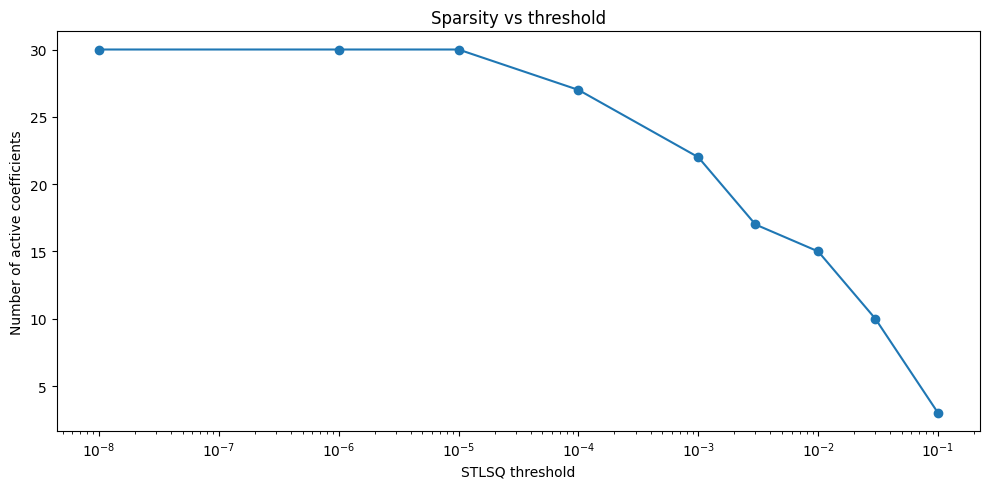

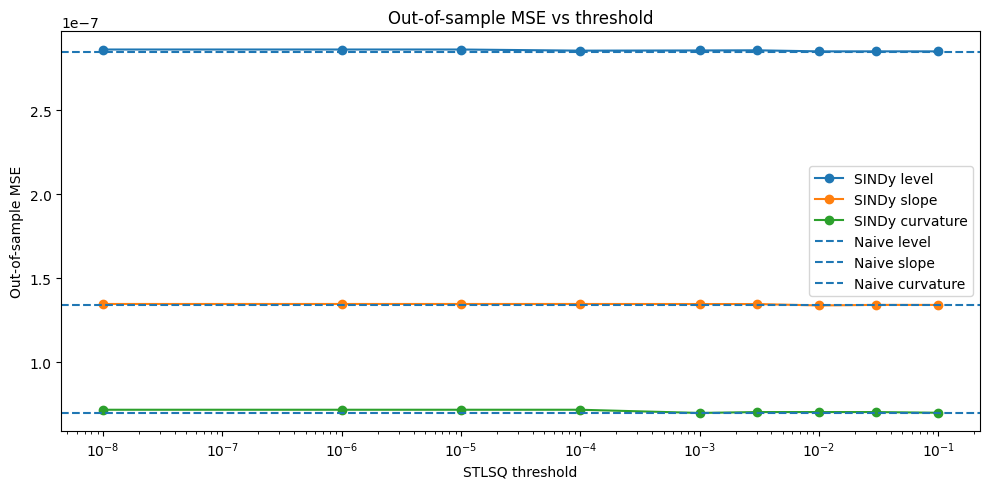

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(
    threshold_sweep_extended["threshold"],
    threshold_sweep_extended["active_terms_total"],
    marker="o",
)
plt.xscale("log")
plt.xlabel("STLSQ threshold")
plt.ylabel("Number of active coefficients")
plt.title("Sparsity vs threshold")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(
    threshold_sweep_extended["threshold"],
    threshold_sweep_extended["mse_level"],
    marker="o",
    label="SINDy level",
)
plt.plot(
    threshold_sweep_extended["threshold"],
    threshold_sweep_extended["mse_slope"],
    marker="o",
    label="SINDy slope",
)
plt.plot(
    threshold_sweep_extended["threshold"],
    threshold_sweep_extended["mse_curvature"],
    marker="o",
    label="SINDy curvature",
)

plt.axhline(mse_naive[0], linestyle="--", label="Naive level")
plt.axhline(mse_naive[1], linestyle="--", label="Naive slope")
plt.axhline(mse_naive[2], linestyle="--", label="Naive curvature")

plt.xscale("log")
plt.xlabel("STLSQ threshold")
plt.ylabel("Out-of-sample MSE")
plt.title("Out-of-sample MSE vs threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
best_threshold_idx = threshold_sweep_extended["avg_mse"].idxmin()
best_threshold = threshold_sweep_extended.loc[best_threshold_idx, "threshold"]

print("Best threshold by average MSE:", best_threshold)

Xi_best, names_best = fit_discrete_sindy(
    X_train,
    Y_train,
    degree=2,
    threshold=best_threshold,
    max_iter=10,
)

Y_test_hat_best = predict_discrete_sindy(
    X_test,
    Xi_best,
    degree=2,
)

best_mse = np.mean((Y_test - Y_test_hat_best) ** 2, axis=0)

best_coef_table = pd.DataFrame(
    Xi_best,
    index=names_best,
    columns=target_names,
)

print("Best model MSE by factor:", best_mse)
print("Naive MSE by factor:", mse_naive)
print()
print("Best coefficient table:")
print(best_coef_table)
print()
print("Recovered equations at best threshold:")
print_equations(names_best, Xi_best, target_names)

Best threshold by average MSE: 0.1
Best model MSE by factor: [2.84944580e-07 1.34114501e-07 6.99720269e-08]
Naive MSE by factor: [2.84841683e-07 1.34120240e-07 7.00561122e-08]

Best coefficient table:
      Delta level  Delta slope  Delta curvature
1        0.000000     0.000000         0.000000
x1       0.000000     0.000000         0.000000
x2       0.000000     0.000000         0.000000
x3       0.000000     0.000000         0.000000
x1^2     0.000000     0.000000         0.000000
x1x2     0.000000     0.000000         0.000000
x1x3     0.000000     0.000000        -0.179575
x2^2     0.000000     0.000000         0.000000
x2x3     0.000000     0.000000         0.000000
x3^2    -0.417483     0.304801         0.000000

Recovered equations at best threshold:
Delta level = -0.417483*x3^2
Delta slope = 0.304801*x3^2
Delta curvature = -0.179575*x1x3


## Conclusion from the threshold sweep

We model daily changes in the yield-curve factor vector:

X_t = [level_t, slope_t, curvature_t]

where:

level_t = 10Y Treasury yield

slope_t = 10Y Treasury yield - 2Y Treasury yield

curvature_t = 2 * 5Y Treasury yield - 2Y Treasury yield - 10Y Treasury yield

The model target is the next daily factor change:

Delta X_next = X_next - X_current

The quadratic SINDy library contains:

[1, level, slope, curvature, level^2, level*slope, level*curvature, slope^2, slope*curvature, curvature^2]

The threshold sweep shows that very small STLSQ thresholds keep the model almost fully dense. For thresholds up to 1e-5, all 30 coefficients remain active. Increasing the threshold enforces stronger sparsity by removing smaller coefficients.

At a high threshold of 0.1, the model becomes much more sparse and keeps only three active terms:

Delta level = -0.417483 * curvature^2

Delta slope = 0.304801 * curvature^2

Delta curvature = -0.179575 * level * curvature

The most economically interpretable equation is:

Delta curvature = -0.179575 * level * curvature

Since nominal rate levels are usually positive, this behaves like a mean-reversion force on curvature.

If curvature is positive, the predicted curvature change is negative.

If curvature is negative, the predicted curvature change is positive.

So the model suggests that curvature is pulled back toward zero, with the strength of this pull depending on the overall rate level.

Out-of-sample validation remains weak. The sparse model at threshold 0.1 slightly improves the MSE for slope and curvature relative to the zero-change baseline, but the improvement is very small. It also slightly worsens the level equation.

Therefore, the result should be interpreted cautiously:

- SINDy can discover interpretable candidate dynamics in yield-curve factors.
- A high threshold produces a sparse and readable equation.
- The strongest candidate structure is level-dependent curvature mean reversion.
- The out-of-sample improvement over the naive zero-change baseline is too small to claim a robust forecasting edge.
- The quadratic library is useful as a demonstration of SINDy's candidate-library mechanism, but strict validation is necessary to avoid over-interpreting noisy financial data.

Overall, this experiment supports the main project message: SINDy works well when the underlying dynamics are sparse and stable, as in the synthetic Vasicek experiment. On real yield-curve data, SINDy can identify plausible candidate structures, but these structures are weak relative to daily noise and should not be treated as physical laws or tradable signals without further validation.

## Regime-specific analysis: recent Fed cutting cycle

SINDy assumes that the underlying dynamics are reasonably stable over the estimation window.

For financial data, this assumption can fail because monetary policy regimes change. Therefore, we repeat the yield-curve factor experiment on a shorter and more homogeneous regime.

We use 2024-09-18 as the start date of the recent cutting cycle. On that date, the FOMC lowered the target range for the federal funds rate by 50 basis points to 4.75%–5.00%.

This regime-specific analysis is exploratory because the sample is much shorter than the full historical sample.

In [26]:
regime_start = "2024-09-18"

yield_curve_regime = yield_curve[
    yield_curve["observation_date"] >= regime_start
].copy()

yield_curve_regime = yield_curve_regime.reset_index(drop=True)

print(yield_curve_regime.head())
print(yield_curve_regime.tail())
print("Number of regime observations:", len(yield_curve_regime))

  observation_date  DGS2  DGS5  DGS10      y2      y5     y10   level   slope  \
0       2024-09-18  3.61  3.47   3.70  0.0361  0.0347  0.0370  0.0370  0.0009   
1       2024-09-19  3.59  3.49   3.73  0.0359  0.0349  0.0373  0.0373  0.0014   
2       2024-09-20  3.55  3.48   3.73  0.0355  0.0348  0.0373  0.0373  0.0018   
3       2024-09-23  3.57  3.51   3.75  0.0357  0.0351  0.0375  0.0375  0.0018   
4       2024-09-24  3.49  3.47   3.74  0.0349  0.0347  0.0374  0.0374  0.0025   

   curvature  
0    -0.0037  
1    -0.0034  
2    -0.0032  
3    -0.0030  
4    -0.0029  
    observation_date  DGS2  DGS5  DGS10      y2      y5     y10   level  \
395       2026-04-21  3.78  3.91   4.30  0.0378  0.0391  0.0430  0.0430   
396       2026-04-22  3.79  3.91   4.30  0.0379  0.0391  0.0430  0.0430   
397       2026-04-23  3.83  3.96   4.34  0.0383  0.0396  0.0434  0.0434   
398       2026-04-24  3.78  3.92   4.31  0.0378  0.0392  0.0431  0.0431   
399       2026-04-27  3.78  3.94   4.35  0.0378 

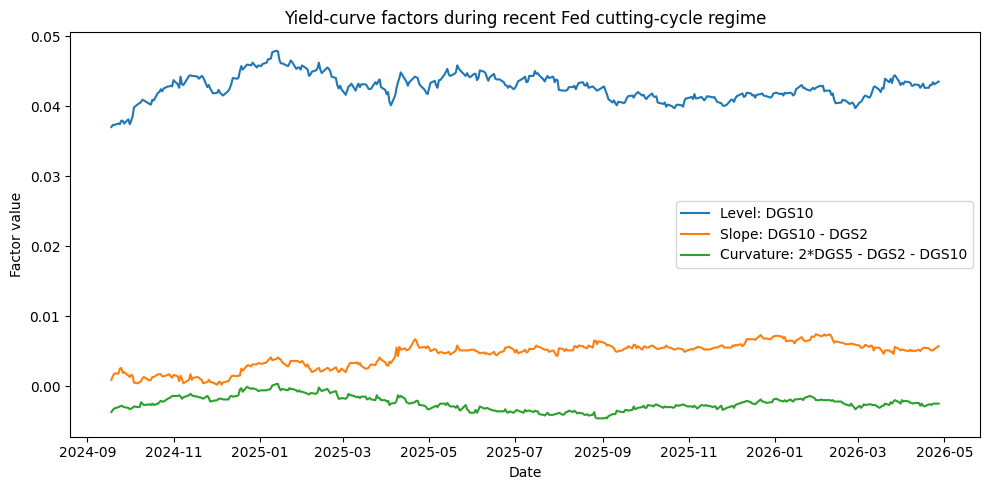

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(
    yield_curve_regime["observation_date"],
    yield_curve_regime["level"],
    label="Level: DGS10",
)
plt.plot(
    yield_curve_regime["observation_date"],
    yield_curve_regime["slope"],
    label="Slope: DGS10 - DGS2",
)
plt.plot(
    yield_curve_regime["observation_date"],
    yield_curve_regime["curvature"],
    label="Curvature: 2*DGS5 - DGS2 - DGS10",
)
plt.xlabel("Date")
plt.ylabel("Factor value")
plt.title("Yield-curve factors during recent Fed cutting-cycle regime")
plt.legend()
plt.tight_layout()
plt.show()

## Prepare regime-specific SINDy problem

We use the same modelling setup as before:

`Delta X_next = X_next - X_current`

with

`X = [level, slope, curvature]`.

The goal is to check whether a shorter monetary-policy regime produces cleaner or more predictive sparse dynamics.

In [28]:
X_factors_regime = yield_curve_regime[factor_cols].to_numpy()

X_current_regime = X_factors_regime[:-1]

X_next_regime = X_factors_regime[1:]

Y_change_regime = X_next_regime - X_current_regime

print("X_current_regime shape:", X_current_regime.shape)

print("Y_change_regime shape:", Y_change_regime.shape)

print("First 5 X_current_regime:")

print(X_current_regime[:5])

print("First 5 Y_change_regime:")

print(Y_change_regime[:5])

X_current_regime shape: (399, 3)
Y_change_regime shape: (399, 3)
First 5 X_current_regime:
[[ 0.037   0.0009 -0.0037]
 [ 0.0373  0.0014 -0.0034]
 [ 0.0373  0.0018 -0.0032]
 [ 0.0375  0.0018 -0.003 ]
 [ 0.0374  0.0025 -0.0029]]
First 5 Y_change_regime:
[[ 3.e-04  5.e-04  3.e-04]
 [ 0.e+00  4.e-04  2.e-04]
 [ 2.e-04  0.e+00  2.e-04]
 [-1.e-04  7.e-04  1.e-04]
 [ 5.e-04  1.e-04  1.e-04]]


In [29]:
split_idx_regime = int(0.7 * len(X_current_regime))

X_train_regime = X_current_regime[:split_idx_regime]
Y_train_regime = Y_change_regime[:split_idx_regime]

X_test_regime = X_current_regime[split_idx_regime:]
Y_test_regime = Y_change_regime[split_idx_regime:]

print("Regime train samples:", len(X_train_regime))
print("Regime test samples:", len(X_test_regime))

Regime train samples: 279
Regime test samples: 120


## Regime model 1: linear SINDy library

We first fit the linear library:

`[1, level, slope, curvature]`

This is the sparse linear factor-change model within the recent cutting-cycle regime.

In [30]:
Xi_linear_regime, names_linear_regime = fit_discrete_sindy(
    X_train_regime,
    Y_train_regime,
    degree=1,
    threshold=1e-8,
    max_iter=10,
)

Y_test_hat_linear_regime = predict_discrete_sindy(
    X_test_regime,
    Xi_linear_regime,
    degree=1,
)

print("Feature names:", names_linear_regime)
print("Xi_linear_regime:")
print(Xi_linear_regime)
print()
print("Recovered linear regime equations:")
print_equations(names_linear_regime, Xi_linear_regime, target_names)

Feature names: ['1', 'x1', 'x2', 'x3']
Xi_linear_regime:
[[ 2.45055047e-03 -9.09778786e-05 -8.03655088e-05]
 [-5.37036783e-02  4.07203628e-03  1.78173185e-03]
 [-1.59023551e-02 -3.45415437e-02 -3.40925427e-02]
 [ 2.78931733e-02 -2.51400770e-02 -5.54274153e-02]]

Recovered linear regime equations:
Delta level = 0.00245055 + -0.0537037*x1 + -0.0159024*x2 + 0.0278932*x3
Delta slope = -9.09779e-05 + 0.00407204*x1 + -0.0345415*x2 + -0.0251401*x3
Delta curvature = -8.03655e-05 + 0.00178173*x1 + -0.0340925*x2 + -0.0554274*x3


## Regime model 2: quadratic and mixed SINDy library

We now allow quadratic and mixed terms:

`[1, level, slope, curvature, level^2, level*slope, level*curvature, slope^2, slope*curvature, curvature^2]`

In [31]:
Xi_quad_regime, names_quad_regime = fit_discrete_sindy(
    X_train_regime,
    Y_train_regime,
    degree=2,
    threshold=1e-8,
    max_iter=10,
)

Y_test_hat_quad_regime = predict_discrete_sindy(
    X_test_regime,
    Xi_quad_regime,
    degree=2,
)

print("Feature names:", names_quad_regime)
print("Xi_quad_regime:")
print(Xi_quad_regime)
print()
print("Recovered quadratic regime equations:")
print_equations(names_quad_regime, Xi_quad_regime, target_names)

Feature names: ['1', 'x1', 'x2', 'x3', 'x1^2', 'x1x2', 'x1x3', 'x2^2', 'x2x3', 'x3^2']
Xi_quad_regime:
[[-2.26542845e-02 -6.75593742e-03 -8.12624448e-03]
 [ 1.17016933e+00  3.15282916e-01  1.91096237e-01]
 [-1.56016588e+00  2.74899301e-01  1.26429817e+00]
 [-1.80822115e+00  1.94041384e-01 -1.02090552e+00]
 [-1.48034180e+01 -3.71092510e+00 -3.12527096e-01]
 [ 3.58300091e+01 -3.83447904e+00 -2.79629258e+01]
 [ 4.38672323e+01 -4.45955724e+00  1.62421527e+01]
 [-2.38798071e+01 -1.88145272e+01 -2.82176510e+00]
 [-8.30726065e+01  1.26877369e+01  5.27276894e+01]
 [-6.30056215e+01  1.97903445e+01  7.52470192e+00]]

Recovered quadratic regime equations:
Delta level = -0.0226543 + 1.17017*x1 + -1.56017*x2 + -1.80822*x3 + -14.8034*x1^2 + 35.83*x1x2 + 43.8672*x1x3 + -23.8798*x2^2 + -83.0726*x2x3 + -63.0056*x3^2
Delta slope = -0.00675594 + 0.315283*x1 + 0.274899*x2 + 0.194041*x3 + -3.71093*x1^2 + -3.83448*x1x2 + -4.45956*x1x3 + -18.8145*x2^2 + 12.6877*x2x3 + 19.7903*x3^2
Delta curvature = -0.008126

## Regime out-of-sample validation

We compare the regime-specific SINDy models against the zero-change baseline.

Because the regime sample is short, these results should be interpreted as exploratory.

In [34]:
zero_change_hat_regime = np.zeros_like(Y_test_regime)

mse_naive_regime = np.mean((Y_test_regime - zero_change_hat_regime) ** 2, axis=0)
mse_linear_regime = np.mean((Y_test_regime - Y_test_hat_linear_regime) ** 2, axis=0)
mse_quad_regime = np.mean((Y_test_regime - Y_test_hat_quad_regime) ** 2, axis=0)

results_regime = pd.DataFrame({
    "factor": factor_cols,
    "mse_naive_zero_change": mse_naive_regime,
    "mse_linear_sindy": mse_linear_regime,
    "mse_quadratic_sindy": mse_quad_regime,
    "linear_improvement_vs_naive": mse_naive_regime - mse_linear_regime,
    "quadratic_improvement_vs_naive": mse_naive_regime - mse_quad_regime,
})

results_regime["linear_improvement_pct"] = (
    results_regime["linear_improvement_vs_naive"]
    / results_regime["mse_naive_zero_change"]
) * 100

results_regime["quadratic_improvement_pct"] = (
    results_regime["quadratic_improvement_vs_naive"]
    / results_regime["mse_naive_zero_change"]
) * 100

print(results_regime)

      factor  mse_naive_zero_change  mse_linear_sindy  mse_quadratic_sindy  \
0      level           1.503333e-07      1.454893e-07         1.768461e-07   
1      slope           6.083333e-08      6.451882e-08         8.455470e-08   
2  curvature           4.750000e-08      5.139549e-08         5.507453e-08   

   linear_improvement_vs_naive  quadratic_improvement_vs_naive  \
0                 4.844003e-09                   -2.651280e-08   
1                -3.685482e-09                   -2.372136e-08   
2                -3.895493e-09                   -7.574531e-09   

   linear_improvement_pct  quadratic_improvement_pct  
0                3.222175                 -17.636009  
1               -6.058326                 -38.994019  
2               -8.201037                 -15.946382  


In [35]:
linear_coef_table_regime = pd.DataFrame(
    Xi_linear_regime,
    index=names_linear_regime,
    columns=target_names,
)

quad_coef_table_regime = pd.DataFrame(
    Xi_quad_regime,
    index=names_quad_regime,
    columns=target_names,
)

print("Linear regime coefficient table:")
print(linear_coef_table_regime)
print()
print("Quadratic regime coefficient table:")

Linear regime coefficient table:
    Delta level  Delta slope  Delta curvature
1      0.002451    -0.000091        -0.000080
x1    -0.053704     0.004072         0.001782
x2    -0.015902    -0.034542        -0.034093
x3     0.027893    -0.025140        -0.055427

Quadratic regime coefficient table:
      Delta level  Delta slope  Delta curvature
1       -0.022654    -0.006756        -0.008126
x1       1.170169     0.315283         0.191096
x2      -1.560166     0.274899         1.264298
x3      -1.808221     0.194041        -1.020906
x1^2   -14.803418    -3.710925        -0.312527
x1x2    35.830009    -3.834479       -27.962926
x1x3    43.867232    -4.459557        16.242153
x2^2   -23.879807   -18.814527        -2.821765
x2x3   -83.072607    12.687737        52.727689
x3^2   -63.005622    19.790344         7.524702


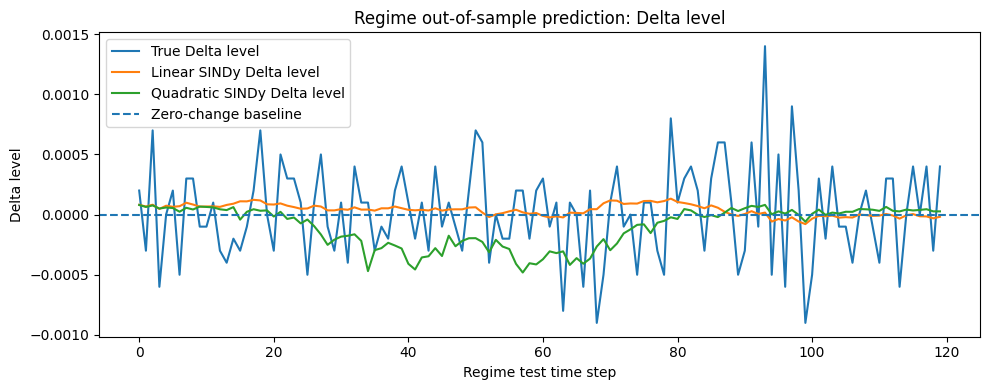

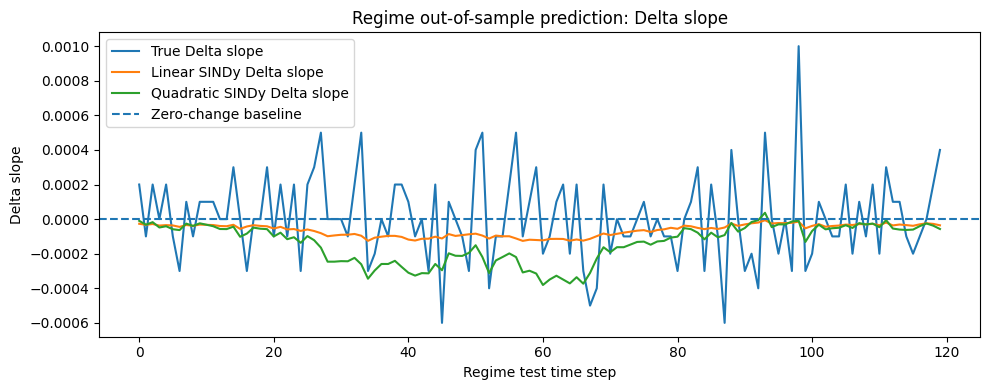

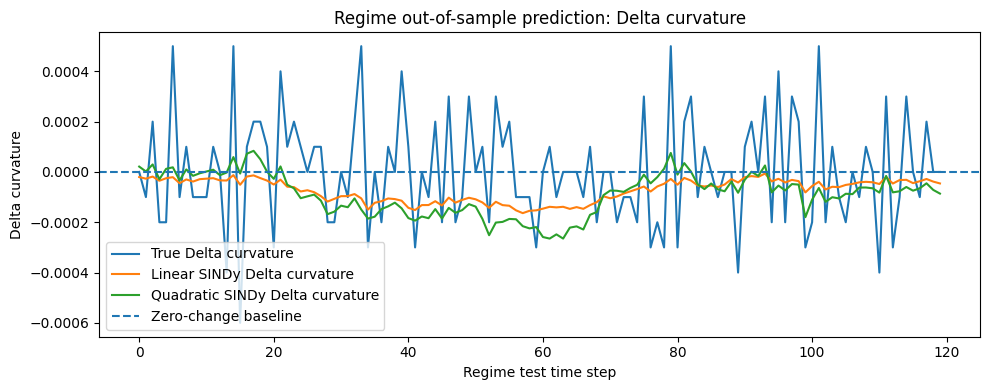

In [36]:
n_plot_regime = len(Y_test_regime)

for i, factor in enumerate(factor_cols):
    plt.figure(figsize=(10, 4))
    plt.plot(Y_test_regime[:n_plot_regime, i], label=f"True Delta {factor}")
    plt.plot(
        Y_test_hat_linear_regime[:n_plot_regime, i],
        label=f"Linear SINDy Delta {factor}",
    )
    plt.plot(
        Y_test_hat_quad_regime[:n_plot_regime, i],
        label=f"Quadratic SINDy Delta {factor}",
    )
    plt.axhline(0.0, linestyle="--", label="Zero-change baseline")
    plt.xlabel("Regime test time step")
    plt.ylabel(f"Delta {factor}")
    plt.title(f"Regime out-of-sample prediction: Delta {factor}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Regime-specific interpretation

The regime-specific experiment tests whether SINDy performs better when the estimation window is restricted to a more homogeneous monetary-policy environment.

This is motivated by the fact that financial dynamics are often regime-dependent. A single equation over the full historical sample may be too restrictive.

If the regime-specific model improves relative to the zero-change baseline, this suggests that SINDy benefits from a more stable local regime.

If it still fails to beat the zero-change baseline, this suggests that even within the recent cutting-cycle regime, daily yield-curve factor changes remain too noisy for reliable one-day prediction.

Because the sample starts only in September 2024, this analysis is exploratory and should not be over-interpreted.

## Regime-specific conclusion

Restricting the estimation window to the recent Fed cutting-cycle regime changes the results.

The linear SINDy model finds stronger and more interpretable mean-reversion-like self-effects than in the full historical sample:

- level -> Delta level is negative
- slope -> Delta slope is negative
- curvature -> Delta curvature is negative

This suggests that estimating SINDy within a more homogeneous monetary-policy regime can produce cleaner candidate dynamics.

However, out-of-sample validation is mixed. The linear model improves the level equation relative to the zero-change baseline by about 3.2%, but it performs worse for slope and curvature.

The quadratic model performs worse across all three factors. This is likely because the regime sample is short and the quadratic library is too flexible, increasing variance and overfitting risk.

Overall, the regime-specific analysis supports a cautious conclusion: regime selection can make the discovered equations more interpretable, but it does not automatically create robust predictive power. For short financial samples, simple linear models may generalize better than larger nonlinear libraries.